<a href="https://colab.research.google.com/github/dgonzales1222/pml_exercises/blob/main/assignment_04/dgonzales_assignment_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 04 - Fine-Tuning and Model Deployment of MNIST Model

**Name:** Danilo III O. Gonzales <br>
**Course:** Practical Machine Learning <br>
**Date:** June 6, 2026

---

# Fine-Tune a Pre-trained CNN on MNIST (PyTorch)

This notebook fine-tunes a **pre-trained ResNet18** for MNIST digit classification, trains for a couple of epochs, and saves the weights as `mnist_cnn.pth` for later deployment (e.g. Gradio on Hugging Face Spaces).

**Tip:** In Colab, enable GPU via *Runtime → Change runtime type → GPU*.

## 1. Imports & Device

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps"  if hasattr(torch.backends, "mps") and torch.backends.mps.is_available() else
    "cpu"
)
print("Using device:", device)

Using device: cpu


## 2. Data Pipeline

MNIST is grayscale 28×28. ResNet expects 3-channel images, so we **replicate the single channel to 3** and keep the native 28×28 resolution. We normalize with ImageNet statistics to match the pre-trained backbone.

*Note:* ResNet18 is originally designed for 224×224 ImageNet images, and at that resolution fine-tuning on MNIST typically reaches around 96% test accuracy. It also performs well on uploaded MNIST style images. However, when the input comes from the Gradio drawing pad, performance drops noticeably. The upsampled brush strokes don't match the smoothed, interpolated 224×224 MNIST images the model trained on. Resizing the input back to MNIST's native 28×28 brings validation accuracy down to about 70%, but real world performance on drawn digits improves because the training and inference distributions now match.

In [ ]:
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_ds = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# Subset for faster fine-tuning demo (comment out to use full dataset)
from torch.utils.data import Subset
train_ds = Subset(train_ds, range(12000))
test_ds  = Subset(test_ds,  range(2000))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=2)
print(f"Train: {len(train_ds)}  Test: {len(test_ds)}")

Train: 12000  Test: 2000


## 3. Load Pre-trained CNN & Adapt the Head

We load ResNet18 pre-trained on ImageNet, **freeze the backbone**, and replace the final fully-connected layer with a fresh 10-class layer. Only the new head is trained — this is the fine-tuning step.

In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all pre-trained layers
for param in model.parameters():
    param.requires_grad = False

# Replace classifier head (trainable)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)

model = model.to(device)
print(model.fc)

Linear(in_features=512, out_features=10, bias=True)


## 4. Loss & Optimizer

Only the new head's parameters are passed to the optimizer.

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

## 5. Fine-Tune for a Couple of Epochs

Epoch 1/30 | loss=1.3670 | acc=56.63%
Epoch 2/30 | loss=0.9778 | acc=69.28%
Epoch 3/30 | loss=0.9029 | acc=71.53%
Epoch 4/30 | loss=0.8365 | acc=73.23%
Epoch 5/30 | loss=0.8256 | acc=73.26%
Epoch 6/30 | loss=0.8023 | acc=73.98%
Epoch 7/30 | loss=0.7797 | acc=75.22%
Epoch 8/30 | loss=0.7734 | acc=75.02%
Epoch 9/30 | loss=0.7577 | acc=75.60%
Epoch 10/30 | loss=0.7408 | acc=76.05%
Epoch 11/30 | loss=0.7389 | acc=75.92%
Epoch 12/30 | loss=0.7281 | acc=76.04%
Epoch 13/30 | loss=0.7367 | acc=76.13%
Epoch 14/30 | loss=0.7309 | acc=76.22%
Epoch 15/30 | loss=0.7296 | acc=75.88%
Epoch 16/30 | loss=0.7248 | acc=76.45%
Epoch 17/30 | loss=0.7285 | acc=76.31%
Epoch 18/30 | loss=0.7096 | acc=76.84%
Epoch 19/30 | loss=0.7144 | acc=76.69%
Epoch 20/30 | loss=0.6984 | acc=76.97%
Epoch 21/30 | loss=0.7180 | acc=76.12%
Epoch 22/30 | loss=0.7039 | acc=76.95%
Epoch 23/30 | loss=0.7031 | acc=77.31%
Epoch 24/30 | loss=0.7063 | acc=77.03%
Epoch 25/30 | loss=0.7022 | acc=77.15%
Epoch 26/30 | loss=0.7010 | acc=77

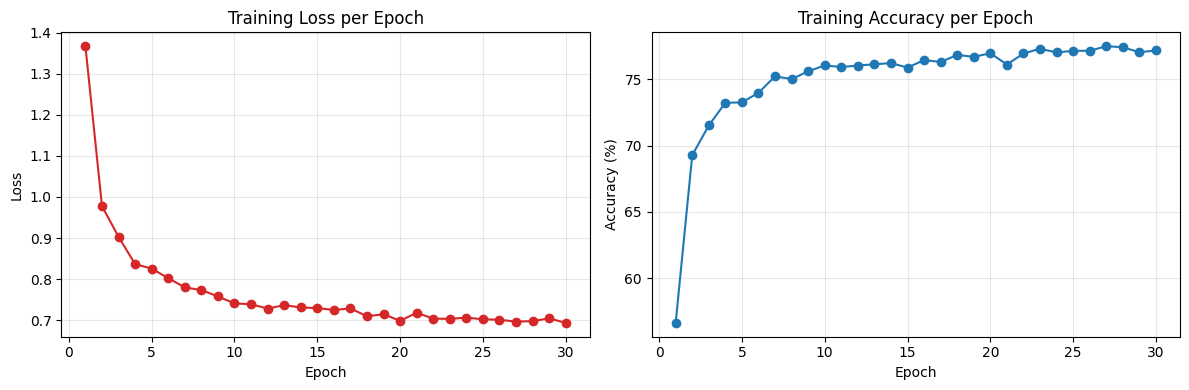

In [ ]:
import matplotlib.pyplot as plt

EPOCHS = 30
train_losses, train_accs = [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, pred = outputs.max(1)
        correct += pred.eq(labels).sum().item()
        total   += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    print(f"Epoch {epoch+1}/{EPOCHS} | loss={epoch_loss:.4f} | acc={epoch_acc:.2f}%")

# --- Plot ---
epochs_range = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, train_losses, marker="o", color="tab:red")
ax1.set_title("Training Loss per Epoch")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, train_accs, marker="o", color="tab:blue")
ax2.set_title("Training Accuracy per Epoch")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)"); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Evaluate on Test Set

In [ ]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, pred = outputs.max(1)
        correct += pred.eq(labels).sum().item()
        total   += labels.size(0)

print(f"Test accuracy: {100*correct/total:.2f}%")

Test accuracy: 73.40%


## 7. Save the Weights as `.pth`

This file is what you'll upload to your Hugging Face Space alongside `app.py`.

In [ ]:
torch.save(model.state_dict(), "mnist_cnn.pth")
print("Saved -> mnist_cnn.pth")

# In Colab, download with:
# from google.colab import files
# files.download("mnist_cnn.pth")

Saved -> mnist_cnn.pth


## 8. Export Sample Images for the Gradio App

Save ~10 random MNIST test images as PNGs. Upload these to the `examples/` folder of your Hugging Face Space so the Gradio `Examples` panel has clickable inputs.

In [ ]:
import os, random
from PIL import ImageOps
from torchvision import datasets

os.makedirs("examples", exist_ok=True)

raw_test = datasets.MNIST(root="./data", train=False, download=True)
indices = random.sample(range(len(raw_test)), 10)

for i, idx in enumerate(indices):
    img, lbl = raw_test[idx]
    # MNIST is white-on-black; invert so the saved PNG looks like real handwriting
    ImageOps.invert(img.convert("L")).save(f"examples/sample_{i}_label{lbl}.png")

print("Saved 10 example images to ./examples/")
# In Colab, zip and download:
# !zip -r examples.zip examples
# from google.colab import files
# files.download("examples.zip")

Saved 10 example images to ./examples/


---
### Notes for deployment
- To **rebuild the model** in your Gradio app, recreate the exact architecture (ResNet18 with `fc = Linear(num_features, 10)`) then `load_state_dict(torch.load("mnist_cnn.pth"))`.
- Preprocessing in the app **must match** this notebook (resize 28×28, grayscale→3 channels, ImageNet normalize).
- A Gradio Sketchpad draws **white-on-black**; MNIST is **black-on-white** — invert the drawing before inference if needed.